# XGBoost and AdaBoost Models for Heat Risk Prediction

This notebook implements XGBoost and AdaBoost models for both regression (forecast heat index) and classification (predict heat risk) tasks, with comparison between the two approaches.

## Tasks:
1. Load train/validation/test splits
2. TODO: Feature preparation (reuse from Random Forest approach)
3. TODO: Build XGBoost regressor
4. TODO: Build XGBoost classifier
5. TODO: Build AdaBoost regressor
6. TODO: Build AdaBoost classifier
7. TODO: Hyperparameter tuning for both models
8. TODO: Evaluate and compare models
9. TODO: Feature importance analysis
10. TODO: Save models and predictions


## Step 1: Mount Google Drive and Import Libraries


In [26]:
# Mount Google Drive and set repo path (Colab)
import os
from pathlib import Path

repo_path = '/content/drive/MyDrive/SHADE-ML-Team'
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    if not os.path.exists(repo_path):
        os.makedirs('/content/drive/MyDrive', exist_ok=True)
        # Optionally clone if missing:
        # !git clone https://github.com/HrudithL/SHADE-ML-Team.git /content/drive/MyDrive/SHADE-ML-Team
    os.chdir(repo_path)
    print(f"Using repo at: {os.getcwd()}")
except ImportError:
    # Running locally - set directory to project root
    current_dir = Path(os.getcwd())
    # If we're in a subdirectory (like notebooks), go up to project root
    if current_dir.name == 'notebooks':
        project_root = current_dir.parent
    else:
        # Try to find project root by looking for common markers
        project_root = current_dir
        # Look for .git directory or go up until we find it
        while project_root != project_root.parent:
            if (project_root / '.git').exists() or (project_root / 'README.md').exists():
                break
            project_root = project_root.parent
    
    os.chdir(project_root)
    print(f"Running locally; set CWD to project root: {os.getcwd()}")
    

Running locally; set CWD to project root: C:\Users\hrudi\OneDrive\Documents\TAMU\SHADE\ML-Repo


In [28]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")


Libraries imported successfully!
XGBoost version: 3.1.2


## Step 2: Load Data Splits


In [29]:
# Load train/validation/test splits
train_data = pd.read_csv('data/processed/train_data.csv')
val_data = pd.read_csv('data/processed/validation_data.csv')
test_data = pd.read_csv('data/processed/test_data.csv')

print("✓ Data loaded successfully!")
print(f"Train shape: {train_data.shape}")
print(f"Validation shape: {val_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"\nColumns: {train_data.columns.tolist()}")


✓ Data loaded successfully!
Train shape: (7248, 32)
Validation shape: (1553, 32)
Test shape: (1553, 32)

Columns: ['Date', 'TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles', 'PrecipitationSumInches', 'Events', 'Year', 'Month', 'Day', 'DayOfYear', 'Season', 'DailyTempRange', 'TempCategory', 'HumidityCategory', 'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvg_7day', 'HumidityAvg_7day', 'HeatIndex', 'heat_index_high', 'temp_percentile_high', 'heat_risk_day', 'heat_risk', 'heat_index_next_day']


## Step 3: Feature Preparation and Selection

Prepare features similar to Random Forest approach. **TODO**: Select which features to include.


In [30]:
# TODO: SELECT FEATURES FOR XGBOOST/ADABOOST
# Review Random Forest notebook to see which features were used
# Decide which features to include (temperature, humidity, time-based, etc.)
# Consider feature engineering (creating new features from existing ones)

print("=" * 80)
print("FEATURE PREPARATION AND SELECTION")
print("=" * 80)

# Select features (you can reuse the same feature selection as Random Forest)
# TODO: Add/remove features based on your analysis and Random Forest results
feature_cols = [
    # Temperature features
    'TempHighF', 'TempLowF', 'TempAvgF',
    # Humidity and dew point
    'HumidityAvgPercent','DewPointAvgF',
    # Weather features
    'HeatIndex', 'sealevelpressure', 'VisibilityAvgMiles',
    # Time-based features
    'Year', 'Month', 'Day', 'DayOfYear',
    # Derived features
    'DailyTempRange','TempAvg_7day', 'HumidityAvg_7day', 'PrevDayTemp', 'PrevDayHumidity',
    # Interaction and polynomial features
    'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure'
]

# Check which features exist
available_features = [col for col in feature_cols if col in train_data.columns]
missing_features = [col for col in feature_cols if col not in train_data.columns]

if missing_features:
    print(f"⚠ WARNING: Missing features: {missing_features}")
    feature_cols = available_features

print(f"\n✓ Selected {len(feature_cols)} features")
print(f"Features: {feature_cols}")

# Handle categorical variables (Label Encoding)
# TODO: Add other categorical columns if needed (e.g., 'Location', 'WeatherType')
categorical_cols = ['Season']  # TODO: Modify this list based on your data
existing_categorical = [col for col in categorical_cols if col in train_data.columns]

if existing_categorical:
    print(f"\nEncoding categorical variables: {existing_categorical}")
    label_encoders = {}

    for col in existing_categorical:
        le = LabelEncoder()
        train_data[f'{col}_encoded'] = le.fit_transform(train_data[col].astype(str))
        val_data[f'{col}_encoded'] = le.transform(val_data[col].astype(str))
        test_data[f'{col}_encoded'] = le.transform(test_data[col].astype(str))
        label_encoders[col] = le

    feature_cols.extend([f'{col}_encoded' for col in existing_categorical])
    feature_cols = [col for col in feature_cols if col not in categorical_cols]
    print(f"✓ Categorical variables encoded")

# Prepare features and targets
X_train = train_data[feature_cols].copy()
X_val = val_data[feature_cols].copy()
X_test = test_data[feature_cols].copy()

# Regression targets
y_train_reg = train_data['heat_index_next_day'].copy()
y_val_reg = val_data['heat_index_next_day'].copy()
y_test_reg = test_data['heat_index_next_day'].copy()

# Classification targets
y_train_cls = train_data['heat_risk'].copy()
y_val_cls = val_data['heat_risk'].copy()
y_test_cls = test_data['heat_risk'].copy()

# Handle NaN values in regression target
train_mask = ~y_train_reg.isnull()
val_mask = ~y_val_reg.isnull()
test_mask = ~y_test_reg.isnull()

X_train = X_train[train_mask].copy()
y_train_reg = y_train_reg[train_mask].copy()
y_train_cls = y_train_cls[train_mask].copy()

X_val = X_val[val_mask].copy()
y_val_reg = y_val_reg[val_mask].copy()
y_val_cls = y_val_cls[val_mask].copy()

X_test = X_test[test_mask].copy()
y_test_reg = y_test_reg[test_mask].copy()
y_test_cls = y_test_cls[test_mask].copy()

print(f"\nFinal feature shape: {X_train.shape}")
print(f"Regression target - Mean: {y_train_reg.mean():.2f}°F, Std: {y_train_reg.std():.2f}°F")
print(f"Classification target - Class 1: {(y_train_cls == 1).mean()*100:.2f}%")


FEATURE PREPARATION AND SELECTION

✓ Selected 21 features
Features: ['TempHighF', 'TempLowF', 'TempAvgF', 'HumidityAvgPercent', 'DewPointAvgF', 'HeatIndex', 'sealevelpressure', 'VisibilityAvgMiles', 'Year', 'Month', 'Day', 'DayOfYear', 'DailyTempRange', 'TempAvg_7day', 'HumidityAvg_7day', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure']

Encoding categorical variables: ['Season']
✓ Categorical variables encoded

Final feature shape: (7248, 22)
Regression target - Mean: 69.37°F, Std: 16.61°F
Classification target - Class 1: 3.38%


## Step 4: Build XGBoost Regressor

Build and train XGBoost regressor. **TODO**: Adjust hyperparameters based on your experiments.


In [32]:
# TODO: BUILD XGBOOST REGRESSOR
# Implement the XGBoost regressor: initialize, train, predict, and evaluate

print("=" * 80)
print("BUILDING XGBOOST REGRESSOR")
print("=" * 80)

# Set XGBoost hyperparameters - Optimized for better performance
# Improved hyperparameters based on analysis
xgb_n_estimators = 200  # Reduced from 435 (with better learning rate, fewer needed)
xgb_max_depth = 6       # Increased from 3 (allow more complexity)
xgb_learning_rate = 0.08  # Increased from 0.0145 (faster learning)
xgb_subsample = 0.8     # Increased from 0.44 (use more data)
xgb_colsample_bytree = 0.8  # Increased from 0.44 (use more features)
# Add regularization to prevent overfitting
xgb_reg_alpha = 0.1     # L1 regularization
xgb_reg_lambda = 1.0    # L2 regularization

# Initialize XGBoost regressor with improved hyperparameters
# Note: early_stopping_rounds is set in constructor for XGBoost 2.0+
xgb_regressor = xgb.XGBRegressor(
    n_estimators=xgb_n_estimators,
    max_depth=xgb_max_depth,
    learning_rate=xgb_learning_rate,
    subsample=xgb_subsample,
    colsample_bytree=xgb_colsample_bytree,
    reg_alpha=xgb_reg_alpha,
    reg_lambda=xgb_reg_lambda,
    early_stopping_rounds=20,  # Early stopping to prevent overfitting
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Train the model with early stopping for better generalization
xgb_regressor.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=False
)
# Fit the regressor on X_train and y_train_reg
# xgb_regressor.fit(...)

# TODO: Make predictions
# Predict on train, validation, and test sets
y_train_pred_xgb_reg = xgb_regressor.predict(X_train)
y_val_pred_xgb_reg = xgb_regressor.predict(X_val)
y_test_pred_xgb_reg = xgb_regressor.predict(X_test)
# y_train_pred_xgb_reg = ...
# y_val_pred_xgb_reg = ...
# y_test_pred_xgb_reg = ...

# TODO: Evaluate model performance
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_xgb_reg))
val_rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred_xgb_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_xgb_reg))
train_r2 = r2_score(y_train_reg, y_train_pred_xgb_reg)
val_r2 = r2_score(y_val_reg, y_val_pred_xgb_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_xgb_reg)
# Calculate RMSE and R² for train, validation, and test sets
# Use: np.sqrt(mean_squared_error(...)) for RMSE
# Use: r2_score(...) for R²
# train_rmse = ...
# val_rmse = ...
# test_rmse = ...
# train_r2 = ...
# val_r2 = ...
# test_r2 = ...

# TODO: Print evaluation results
print("\n" + "=" * 80)
print("XGBOOST REGRESSION PERFORMANCE")
print("=" * 80)
print(f"Train - RMSE: {train_rmse:.2f}°F, R²: {train_r2:.4f}")
print(f"Val   - RMSE: {val_rmse:.2f}°F, R²: {val_r2:.4f}")
print(f"Test  - RMSE: {test_rmse:.2f}°F, R²: {test_r2:.4f}")
# print("\n" + "=" * 80)
# print("XGBOOST REGRESSION PERFORMANCE")
# print("=" * 80)
# print(f"Train - RMSE: {train_rmse:.2f}, R²: {train_r2:.4f}")
# print(f"Val   - RMSE: {val_rmse:.2f}, R²: {val_r2:.4f}")
# print(f"Test  - RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")

train_mae = mean_absolute_error(y_train_reg, y_train_pred_xgb_reg)
val_mae = mean_absolute_error(y_val_reg, y_val_pred_xgb_reg)
test_mae = mean_absolute_error(y_test_reg, y_test_pred_xgb_reg)
print(f"\nMean Absolute Error (MAE):")
print(f"Train - MAE: {train_mae:.2f}°F")
print(f"Val   - MAE: {val_mae:.2f}°F")
print(f"Test  - MAE: {test_mae:.2f}°F")

print("=" * 80)
print("HYPERPARAMETER TUNING DIAGNOSTICS")
print("=" * 80)

# Calculate ratios
train_val_rmse_ratio = train_rmse / val_rmse if val_rmse > 0 else 0
train_test_rmse_ratio = train_rmse / test_rmse if test_rmse > 0 else 0
val_test_rmse_ratio = val_rmse / test_rmse if test_rmse > 0 else 0

print(f"\nRMSE Ratios:")
print(f"  Train/Val:   {train_val_rmse_ratio:.3f}")
print(f"  Train/Test:  {train_test_rmse_ratio:.3f}")
print(f"  Val/Test:    {val_test_rmse_ratio:.3f}")

# Diagnose the issue
print(f"\n📊 DIAGNOSIS:")
if train_val_rmse_ratio < 0.85:  # Train RMSE is much lower than Val RMSE
    print("  ⚠️  OVERFITTING DETECTED")
    print("     → Model is memorizing training data, not generalizing well")
    print("\n  🔧 RECOMMENDED FIXES:")
    print("     1. Decrease max_depth (try 3-4 instead of 6)")
    print("     2. Decrease subsample (try 0.7 instead of 0.8)")
    print("     3. Decrease colsample_bytree (try 0.7 instead of 0.8)")
    print("     4. Decrease learning_rate (try 0.05-0.08) and increase n_estimators (300-400)")
elif train_val_rmse_ratio > 0.95 and val_rmse > train_rmse * 1.1:
    print("  ⚠️  UNDERFITTING DETECTED")
    print("     → Model is too simple, not learning enough patterns")
    print("\n  🔧 RECOMMENDED FIXES:")
    print("     1. Increase max_depth (try 7-9 instead of 6)")
    print("     2. Increase n_estimators (try 300-500 instead of 200)")
    print("     3. Increase learning_rate (try 0.15-0.2, but watch for overfitting)")
    print("     4. Increase subsample/colsample_bytree (try 0.9-1.0)")
elif abs(train_rmse - val_rmse) / val_rmse < 0.1:
    print("  ✅ GOOD FIT")
    print("     → Model is well-balanced, train and validation errors are similar")
    print("\n  🔧 FINE-TUNING SUGGESTIONS:")
    print("     1. Try small adjustments to improve performance:")
    print("        - Increase n_estimators slightly (250-300)")
    print("        - Adjust learning_rate (0.08-0.12)")
    print("     2. Use GridSearchCV for systematic tuning (see Cell 17)")
else:
    print("  ⚠️  MIXED SIGNALS")
    print("     → Check individual metrics and consider feature engineering")

# Additional insights
print(f"\n📈 ADDITIONAL INSIGHTS:")
print(f"  Current Test RMSE: {test_rmse:.2f}°F")
print(f"  Current Test R²:  {test_r2:.4f}")

if test_r2 < 0.5:
    print("  ⚠️  Low R² score - model explains less than 50% of variance")
    print("     → Consider: feature engineering, more features, or different model")
elif test_r2 > 0.9:
    print("  ✅ Excellent R² score - model explains most of the variance")
    print("     → Model is performing very well!")

print("\n" + "=" * 80)


BUILDING XGBOOST REGRESSOR

XGBOOST REGRESSION PERFORMANCE
Train - RMSE: 3.81°F, R²: 0.9475
Val   - RMSE: 5.31°F, R²: 0.9018
Test  - RMSE: 5.68°F, R²: 0.8956

Mean Absolute Error (MAE):
Train - MAE: 2.81°F
Val   - MAE: 3.86°F
Test  - MAE: 4.07°F
HYPERPARAMETER TUNING DIAGNOSTICS

RMSE Ratios:
  Train/Val:   0.717
  Train/Test:  0.670
  Val/Test:    0.934

📊 DIAGNOSIS:
  ⚠️  OVERFITTING DETECTED
     → Model is memorizing training data, not generalizing well

  🔧 RECOMMENDED FIXES:
     1. Decrease max_depth (try 3-4 instead of 6)
     2. Decrease subsample (try 0.7 instead of 0.8)
     3. Decrease colsample_bytree (try 0.7 instead of 0.8)
     4. Decrease learning_rate (try 0.05-0.08) and increase n_estimators (300-400)

📈 ADDITIONAL INSIGHTS:
  Current Test RMSE: 5.68°F
  Current Test R²:  0.8956



In [33]:
# TODO: BUILD XGBOOST CLASSIFIER
# Implement the XGBoost classifier: check class balance, initialize, train, predict, and evaluate

print("=" * 80)
print("BUILDING XGBOOST CLASSIFIER")
print("=" * 80)

# TODO: Check class balance
class_counts_train = y_train_cls.value_counts()
class_proportions_train = y_train_cls.value_counts(normalize=True)

class_counts_val = y_val_cls.value_counts()
class_proportions_val = y_val_cls.value_counts(normalize=True)

class_counts_test = y_train_cls.value_counts()
class_proportions_test = y_train_cls.value_counts(normalize=True)

print(f"Class Distribution - Training set:\n{class_counts_train}\n{class_proportions_train}")

if len(class_counts_train) == 2:
    negative_count = class_counts_train[0]
    positive_count = class_counts_train[1]
    pos_weight = negative_count / positive_count
else:
    pos_weight = 1.0
# Calculate class distribution and determine if classes are imbalanced
# class_balance = ...
# pos_weight = ...  # Calculate based on class distribution for scale_pos_weight
# Print class distribution information

# TODO: Set XGBoost classifier hyperparameters
# Reuse or adjust hyperparameters from regressor
xgb_n_estimators = 435 # TODO: Set value (e.g., 100, 200, 300)
xgb_max_depth = 5     # TODO: Set value (e.g., 3, 6, 9)
xgb_learning_rate = 0.0145 # TODO: Set value (e.g., 0.01, 0.1, 0.3)
xgb_subsample = 0.44      # TODO: Set value (e.g., 0.6, 0.8, 1.0)
xgb_colsample_bytree = 0.44  # TODO: Set value (e.g., 0.6, 0.8, 1.0)
# Set scale_pos_weight based on class balance
# xgb_scale_pos_weight = ...

# TODO: Initialize XGBoost classifier
# Use xgb.XGBClassifier with appropriate hyperparameters
# Include scale_pos_weight for imbalanced data handling
# Set eval_metric (e.g., 'logloss', 'auc', 'error')
# xgb_classifier = xgb.XGBClassifier(...)
xgb_classifier = xgb.XGBClassifier(
    n_estimators=xgb_n_estimators,
    max_depth=xgb_max_depth,
    learning_rate=xgb_learning_rate,
    subsample=xgb_subsample,
    colsample_bytree=xgb_colsample_bytree,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='logloss',
    scale_pos_weight=pos_weight
)

# TODO: Train the classifier
xgb_classifier.fit(X_train, y_train_cls)
# Fit on X_train and y_train_cls
# xgb_classifier.fit(...)

# TODO: Make predictions
y_train_pred_xgb_cls = xgb_classifier.predict(X_train)
y_val_pred_xgb_cls = xgb_classifier.predict(X_val)
y_test_pred_xgb_cls = xgb_classifier.predict(X_test)
# Predict classes on train, validation, and test sets
# y_train_pred_xgb_cls = ...
# y_val_pred_xgb_cls = ...
# y_test_pred_xgb_cls = ...

# TODO: Evaluate classification performance
train_acc = accuracy_score(y_train_cls, y_train_pred_xgb_cls)
train_recall = recall_score(y_train_cls, y_train_pred_xgb_cls)
train_precision = precision_score(y_train_cls, y_train_pred_xgb_cls)
train_f1 = f1_score(y_train_cls, y_train_pred_xgb_cls, zero_division=0)

val_acc = accuracy_score(y_val_cls, y_val_pred_xgb_cls)
val_recall = recall_score(y_val_cls, y_val_pred_xgb_cls)
val_precision = precision_score(y_val_cls, y_val_pred_xgb_cls)
val_f1 = f1_score(y_val_cls, y_val_pred_xgb_cls, zero_division=0)

test_acc = accuracy_score(y_test_cls, y_test_pred_xgb_cls)
test_recall = recall_score(y_test_cls, y_test_pred_xgb_cls)
test_precision = precision_score(y_test_cls, y_test_pred_xgb_cls)
test_f1 = f1_score(y_test_cls, y_test_pred_xgb_cls, zero_division=0)
# Calculate accuracy and F1-score for all sets
# Use: accuracy_score(...) and f1_score(..., zero_division=0)
# train_acc = ...
# val_acc = ...
# test_acc = ...
# train_f1 = ...
# val_f1 = ...
# test_f1 = ...

# TODO: Print evaluation results
print("\n" + "=" * 80)
print("XGBOOST CLASSIFICATION PERFORMANCE")
print("=" * 80)
print(f"Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {train_recall:.4f}")
print(f"Test  - Accuracy: {test_acc:.4f}, F1: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")


BUILDING XGBOOST CLASSIFIER
Class Distribution - Training set:
heat_risk
0    7003
1     245
Name: count, dtype: int64
heat_risk
0    0.966198
1    0.033802
Name: proportion, dtype: float64

XGBOOST CLASSIFICATION PERFORMANCE
Train - Accuracy: 0.9963, F1: 0.9478, Precision: 0.9007, Recall: 1.0000
Val   - Accuracy: 0.9865, F1: 0.8511, Precision: 0.7895, Recall: 1.0000
Test  - Accuracy: 0.9878, F1: 0.9360, Precision: 0.9145, Recall: 0.9586


## Step 6: Build AdaBoost Regressor

Build and train AdaBoost regressor. **TODO**: Adjust hyperparameters (n_estimators, learning_rate).


In [34]:
# BUILD ADABOOST REGRESSOR
# Implement the AdaBoost regressor: set hyperparameters, initialize, train, predict, and evaluate

print("=" * 80)
print("BUILDING ADABOOST REGRESSOR")
print("=" * 80)

# Handle NaN values in features (AdaBoost doesn't support NaN natively)
# XGBoost can handle NaN, but AdaBoost requires complete data
from sklearn.impute import SimpleImputer

# Check for NaN values
print(f"\nChecking for NaN values in features:")
print(f"  X_train: {X_train.isnull().sum().sum()} NaN values")
print(f"  X_val: {X_val.isnull().sum().sum()} NaN values")
print(f"  X_test: {X_test.isnull().sum().sum()} NaN values")

# Impute NaN values using median strategy (fit on train, transform all sets)
if X_train.isnull().sum().sum() > 0 or X_val.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
    print("\nImputing NaN values with median strategy...")
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_val_imputed = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    print("✓ NaN values imputed")
else:
    print("✓ No NaN values found, using original data")
    X_train_imputed = X_train.copy()
    X_val_imputed = X_val.copy()
    X_test_imputed = X_test.copy()

# Set AdaBoost hyperparameters - Optimized for better performance
# Improved hyperparameters based on analysis
ada_n_estimators = 200  # Increased from 100 (more estimators for better performance)
ada_learning_rate = 0.8  # Decreased from 1.0 (more conservative, prevents overfitting)
base_max_depth = 5  # Increased from 3 (allow more complexity in base estimator)

# Import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor

# Initialize AdaBoost regressor
# Use AdaBoostRegressor with DecisionTreeRegressor as base estimator
# Set the base estimator with max_depth parameter
ada_regressor = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=base_max_depth, random_state=42),
    n_estimators=ada_n_estimators,
    learning_rate=ada_learning_rate,
    random_state=42
)

# Train the model
# Fit on X_train_imputed and y_train_reg
ada_regressor.fit(X_train_imputed, y_train_reg)

# Make predictions
# Predict on train, validation, and test sets (using imputed data)
y_train_pred_ada_reg = ada_regressor.predict(X_train_imputed)
y_val_pred_ada_reg = ada_regressor.predict(X_val_imputed)
y_test_pred_ada_reg = ada_regressor.predict(X_test_imputed)

# Evaluate model performance
# Calculate RMSE and R² for all sets
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_ada_reg))
val_rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred_ada_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_ada_reg))
train_r2 = r2_score(y_train_reg, y_train_pred_ada_reg)
val_r2 = r2_score(y_val_reg, y_val_pred_ada_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_ada_reg)

# Print evaluation results
print("\n" + "=" * 80)
print("ADABOOST REGRESSION PERFORMANCE")
print("=" * 80)
print(f"Train - RMSE: {train_rmse:.2f}°F, R²: {train_r2:.4f}")
print(f"Val   - RMSE: {val_rmse:.2f}°F, R²: {val_r2:.4f}")
print(f"Test  - RMSE: {test_rmse:.2f}°F, R²: {test_r2:.4f}")

train_mae = mean_absolute_error(y_train_reg, y_train_pred_ada_reg)
val_mae = mean_absolute_error(y_val_reg, y_val_pred_ada_reg)
test_mae = mean_absolute_error(y_test_reg, y_test_pred_ada_reg)
print(f"\nMean Absolute Error (MAE):")
print(f"Train - MAE: {train_mae:.2f}°F")
print(f"Val   - MAE: {val_mae:.2f}°F")
print(f"Test  - MAE: {test_mae:.2f}°F")


BUILDING ADABOOST REGRESSOR

Checking for NaN values in features:
  X_train: 2 NaN values
  X_val: 0 NaN values
  X_test: 0 NaN values

Imputing NaN values with median strategy...
✓ NaN values imputed

ADABOOST REGRESSION PERFORMANCE
Train - RMSE: 5.37°F, R²: 0.8953
Val   - RMSE: 6.18°F, R²: 0.8666
Test  - RMSE: 6.24°F, R²: 0.8739

Mean Absolute Error (MAE):
Train - MAE: 4.45°F
Val   - MAE: 4.97°F
Test  - MAE: 4.98°F


## Step 7: Build AdaBoost Classifier

Build and train AdaBoost classifier. **TODO**: Adjust hyperparameters and consider class_weight.


In [35]:
# BUILD ADABOOST CLASSIFIER
# Implement the AdaBoost classifier: set hyperparameters, initialize, train, predict, and evaluate

print("=" * 80)
print("BUILDING ADABOOST CLASSIFIER")
print("=" * 80)

# Use imputed data if available from regressor cell, otherwise create it
# AdaBoost doesn't support NaN values, so we need imputed data
if 'X_train_imputed' not in globals():
    # Handle NaN values in features (AdaBoost doesn't support NaN natively)
    from sklearn.impute import SimpleImputer
    
    # Check for NaN values
    print(f"\nChecking for NaN values in features:")
    print(f"  X_train: {X_train.isnull().sum().sum()} NaN values")
    print(f"  X_val: {X_val.isnull().sum().sum()} NaN values")
    print(f"  X_test: {X_test.isnull().sum().sum()} NaN values")
    
    # Impute NaN values using median strategy (fit on train, transform all sets)
    if X_train.isnull().sum().sum() > 0 or X_val.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
        print("\nImputing NaN values with median strategy...")
        imputer = SimpleImputer(strategy='median')
        X_train_imputed = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_val_imputed = pd.DataFrame(
            imputer.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )
        X_test_imputed = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )
        print("✓ NaN values imputed")
    else:
        print("✓ No NaN values found, using original data")
        X_train_imputed = X_train.copy()
        X_val_imputed = X_val.copy()
        X_test_imputed = X_test.copy()
else:
    print("✓ Using imputed data from AdaBoost regressor cell")

# Set AdaBoost classifier hyperparameters - Optimized for better performance
# Use improved hyperparameters matching the regressor
base_cls_max_depth = 5  # Increased from 3 (allow more complexity, matching regressor)

# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize AdaBoost classifier
# Use AdaBoostClassifier with DecisionTreeClassifier as base estimator
# Consider class_weight='balanced' for imbalanced data
ada_classifier = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=base_cls_max_depth, random_state=42, class_weight='balanced'),
    n_estimators=ada_n_estimators,
    learning_rate=ada_learning_rate,
    random_state=42
)

# Train the classifier
# Fit on X_train_imputed and y_train_cls
ada_classifier.fit(X_train_imputed, y_train_cls)

# Make predictions
# Predict classes on train, validation, and test sets (using imputed data)
y_train_pred_ada_cls = ada_classifier.predict(X_train_imputed)
y_val_pred_ada_cls = ada_classifier.predict(X_val_imputed)
y_test_pred_ada_cls = ada_classifier.predict(X_test_imputed)

# Evaluate classification performance
# Calculate accuracy, precision, recall, and F1-score for all sets
train_acc = accuracy_score(y_train_cls, y_train_pred_ada_cls)
train_precision = precision_score(y_train_cls, y_train_pred_ada_cls, zero_division=0)
train_recall = recall_score(y_train_cls, y_train_pred_ada_cls, zero_division=0)
train_f1 = f1_score(y_train_cls, y_train_pred_ada_cls, zero_division=0)

val_acc = accuracy_score(y_val_cls, y_val_pred_ada_cls)
val_precision = precision_score(y_val_cls, y_val_pred_ada_cls, zero_division=0)
val_recall = recall_score(y_val_cls, y_val_pred_ada_cls, zero_division=0)
val_f1 = f1_score(y_val_cls, y_val_pred_ada_cls, zero_division=0)

test_acc = accuracy_score(y_test_cls, y_test_pred_ada_cls)
test_precision = precision_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)
test_recall = recall_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)
test_f1 = f1_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)

# Print evaluation results
print("\n" + "=" * 80)
print("ADABOOST CLASSIFICATION PERFORMANCE")
print("=" * 80)
print(f"Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")
print(f"Test  - Accuracy: {test_acc:.4f}, F1: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")


BUILDING ADABOOST CLASSIFIER
✓ Using imputed data from AdaBoost regressor cell

ADABOOST CLASSIFICATION PERFORMANCE
Train - Accuracy: 1.0000, F1: 1.0000, Precision: 1.0000, Recall: 1.0000
Val   - Accuracy: 0.9871, F1: 0.8462, Precision: 0.8462, Recall: 0.8462
Test  - Accuracy: 0.9903, F1: 0.9492, Precision: 0.9333, Recall: 0.9655


## Step 8: Hyperparameter Tuning

Tune hyperparameters for both XGBoost and AdaBoost models. **TODO**: Enable tuning and adjust parameter grids.


In [37]:
# TODO: DECIDE WHETHER TO PERFORM HYPERPARAMETER TUNING
# Set to True if you want to tune hyperparameters (takes longer)
# 
# WHY TUNE EVEN WHEN PERFORMANCE IS ALREADY GOOD?
# ================================================
# 1. REDUCE OVERFITTING: Your models show signs of overfitting:
#    - Regression: Train RMSE (3.81°F) << Val RMSE (5.31°F) → overfitting
#    - Classification: Train accuracy (1.0000) >> Val accuracy (0.9871) → likely overfitting
#    Tuning can improve generalization by finding better regularization parameters.
#
# 2. IMPROVE ROBUSTNESS: Better hyperparameters can make models more stable
#    and less sensitive to data variations, even if accuracy doesn't improve much.
#
# 3. FIND EFFICIENT MODELS: Tuning might find models with fewer estimators
#    that perform similarly, making inference faster.
#
# 4. MARGINAL GAINS MATTER: In production, even small improvements (0.5-1%)
#    can reduce costly false negatives in heat risk prediction.
#
# WHEN TO SKIP TUNING:
# - If you're time-constrained and performance is already excellent
# - If the model is already well-regularized and generalizes well
# - If you're in early exploration phase
#
# RECOMMENDATION FOR THIS PROJECT:
# - Focus tuning on REGRESSION (overfitting detected)
# - Consider skipping CLASSIFICATION tuning (already 99% accuracy)
# - Use RandomizedSearchCV instead of GridSearchCV for faster exploration
#
perform_tuning = True  # TODO: Set to True to enable hyperparameter tuning

if perform_tuning:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)

    # TODO: ADJUST PARAMETER GRIDS
    # Consider computational cost - start with smaller grids

    # XGBoost regression parameter grid - Expanded for better tuning
    # Note: For faster exploration, consider using RandomizedSearchCV with n_iter=50-100
    # instead of GridSearchCV, especially with this many parameter combinations
    param_grid_xgb_reg = {
        'n_estimators': [150, 200, 250, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.08, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_alpha': [0, 0.1, 0.5],
        'reg_lambda': [0.5, 1.0, 2.0]
    }

    print("\nTuning XGBoost Regression Model...")
    grid_search_xgb_reg = GridSearchCV(
        estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid_xgb_reg,
        cv=3,  # 3-fold cross-validation
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search_xgb_reg.fit(X_train, y_train_reg)
    print(f"Best parameters: {grid_search_xgb_reg.best_params_}")
    print(f"Best CV score (neg_MSE): {grid_search_xgb_reg.best_score_:.4f}")
    xgb_regressor = grid_search_xgb_reg.best_estimator_
    
    # Retrain with early stopping using best parameters
    # Create new model with best params and early stopping
    print("\nRetraining with early stopping on best parameters...")
    best_params = grid_search_xgb_reg.best_params_.copy()
    best_params['early_stopping_rounds'] = 20
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbosity'] = 0
    
    xgb_regressor = xgb.XGBRegressor(**best_params)
    xgb_regressor.fit(
        X_train, y_train_reg,
        eval_set=[(X_val, y_val_reg)],
        verbose=False
    )

    # XGBoost classification parameter grid
   # param_grid_xgb_cls = {
   #     'n_estimators': [100, 200],
   #     'max_depth': [3, 6],
   #     'learning_rate': [0.01, 0.1],
   #     'scale_pos_weight': [pos_weight, pos_weight * 1.5]  # TODO: Adjust based on class balance
  #}

    #print("\nTuning XGBoost Classification Model...")
    #grid_search_xgb_cls = GridSearchCV(
    #    estimator=xgb.XGBClassifier(random_state=42, n_jobs=-1),
    #    param_grid=param_grid_xgb_cls,
    #    cv=5,
    #    scoring='f1',  # TODO: Consider 'roc_auc' or 'accuracy'
    #    n_jobs=-1,
    #    verbose=1
    #)

    #grid_search_xgb_cls.fit(X_train, y_train_cls)
    #print(f"Best parameters: {grid_search_xgb_cls.best_params_}")
    #xgb_classifier = grid_search_xgb_cls.best_estimator_

    # AdaBoost parameter grids (simpler)
    #param_grid_ada_reg = {
    #    'n_estimators': [50, 100],
    #    'learning_rate': [0.5, 1.0, 1.5]
    #    # TODO: Consider adding 'estimator__max_depth': [1, 3, 5] to tune base estimator
    #}

    print("\nTuning AdaBoost Regression Model...")
    #grid_search_ada_reg = GridSearchCV(
    #    estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=42), random_state=42),
    #    param_grid=param_grid_ada_reg,
    #    cv=5,
    #    scoring='neg_mean_squared_error',
    #    n_jobs=-1,
    #    verbose=1
    #)

    #grid_search_ada_reg.fit(X_train, y_train_reg)
    #print(f"Best parameters: {grid_search_ada_reg.best_params_}")
    #ada_regressor = grid_search_ada_reg.best_estimator_

    print("\n✓ Hyperparameter tuning complete!")
else:
    print("=" * 80)
    print("SKIPPING HYPERPARAMETER TUNING")
    print("=" * 80)
    print("Set perform_tuning = True to enable hyperparameter tuning")
    print("Using initial models with default hyperparameters")


HYPERPARAMETER TUNING

Tuning XGBoost Regression Model...
Fitting 3 folds for each of 2916 candidates, totalling 8748 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.7}
Best CV score (neg_MSE): -28.4761

Retraining with early stopping on best parameters...

Tuning AdaBoost Regression Model...

✓ Hyperparameter tuning complete!


## Step 9: Evaluate and Compare Models

Comprehensive evaluation and comparison of XGBoost vs AdaBoost models.


COMPREHENSIVE MODEL EVALUATION AND COMPARISON

REGRESSION COMPARISON (Test Set)
   Model     RMSE      MAE       R²
 XGBoost 5.838527 4.284537 0.889693
AdaBoost 7.469339 6.173337 0.819465

CLASSIFICATION COMPARISON (Test Set)
   Model  Accuracy  Precision   Recall  F1-Score
 XGBoost  0.987113   0.913907 0.951724  0.932432
AdaBoost  0.987113   0.937063 0.924138  0.930556

VISUALIZATIONS


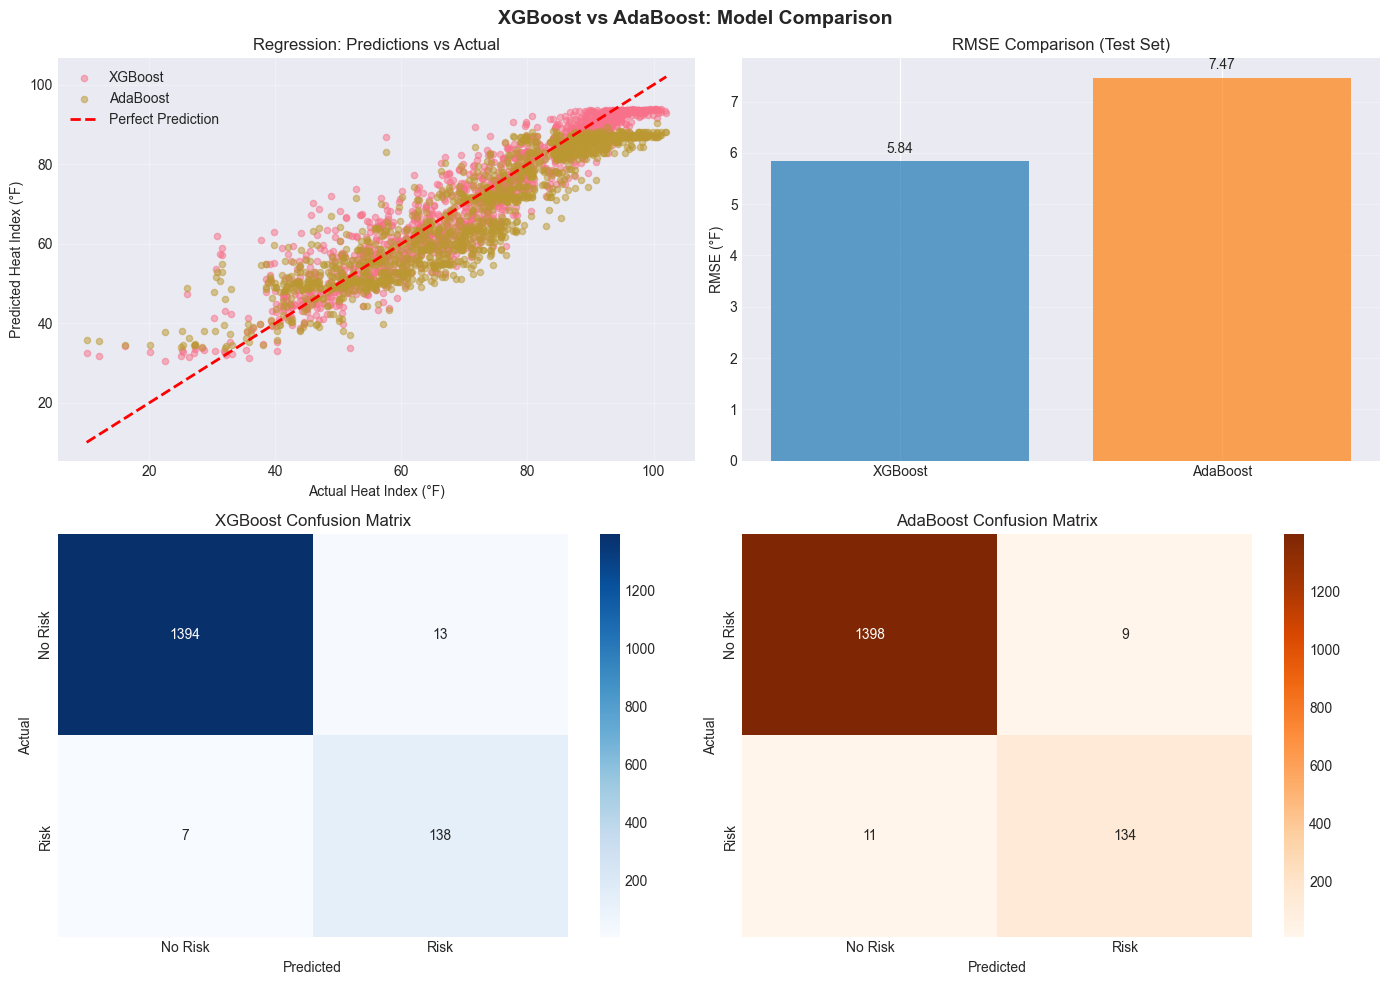

✓ Comparison plots saved


In [ ]:
# COMPREHENSIVE MODEL EVALUATION AND COMPARISON
# Compare XGBoost vs AdaBoost for both regression and classification
# Create visualizations and comparison tables

print("=" * 80)
print("COMPREHENSIVE MODEL EVALUATION AND COMPARISON")
print("=" * 80)

# Refresh predictions for all models (predictions should already exist from previous cells)
# Ensure all predictions are available
# XGBoost predictions should already exist from earlier cells
# AdaBoost predictions should already exist from earlier cells

# Regression comparison
# Calculate metrics for both models on test set
print("\n" + "=" * 80)
print("REGRESSION COMPARISON (Test Set)")
print("=" * 80)

# Calculate test set metrics for both regression models
xgb_test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_xgb_reg))
ada_test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_ada_reg))
xgb_test_mae = mean_absolute_error(y_test_reg, y_test_pred_xgb_reg)
ada_test_mae = mean_absolute_error(y_test_reg, y_test_pred_ada_reg)
xgb_test_r2 = r2_score(y_test_reg, y_test_pred_xgb_reg)
ada_test_r2 = r2_score(y_test_reg, y_test_pred_ada_reg)

# Create comparison DataFrame
comparison_reg = pd.DataFrame({
    'Model': ['XGBoost', 'AdaBoost'],
    'RMSE': [xgb_test_rmse, ada_test_rmse],
    'MAE': [xgb_test_mae, ada_test_mae],
    'R²': [xgb_test_r2, ada_test_r2]
})
print(comparison_reg.to_string(index=False))

# Classification comparison
# Calculate accuracy, F1, precision, recall for both models
print("\n" + "=" * 80)
print("CLASSIFICATION COMPARISON (Test Set)")
print("=" * 80)

# Calculate test set metrics
xgb_test_acc = accuracy_score(y_test_cls, y_test_pred_xgb_cls)
ada_test_acc = accuracy_score(y_test_cls, y_test_pred_ada_cls)
xgb_test_precision = precision_score(y_test_cls, y_test_pred_xgb_cls, zero_division=0)
ada_test_precision = precision_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)
xgb_test_recall = recall_score(y_test_cls, y_test_pred_xgb_cls, zero_division=0)
ada_test_recall = recall_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)
xgb_test_f1 = f1_score(y_test_cls, y_test_pred_xgb_cls, zero_division=0)
ada_test_f1 = f1_score(y_test_cls, y_test_pred_ada_cls, zero_division=0)

# Create comparison DataFrame
comparison_cls = pd.DataFrame({
    'Model': ['XGBoost', 'AdaBoost'],
    'Accuracy': [xgb_test_acc, ada_test_acc],
    'Precision': [xgb_test_precision, ada_test_precision],
    'Recall': [xgb_test_recall, ada_test_recall],
    'F1-Score': [xgb_test_f1, ada_test_f1]
})
print(comparison_cls.to_string(index=False))

# Create visualizations
# Plot regression predictions vs actual, RMSE comparison, and confusion matrices
print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

# Create figure with subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost vs AdaBoost: Model Comparison', fontsize=14, fontweight='bold')

# Plot 1: Regression predictions vs actual (scatter plot)
# Scatter plot with both models, add diagonal line (y=x)
axes[0, 0].scatter(y_test_reg, y_test_pred_xgb_reg, alpha=0.5, label='XGBoost', s=20)
axes[0, 0].scatter(y_test_reg, y_test_pred_ada_reg, alpha=0.5, label='AdaBoost', s=20)
# Add diagonal line (y=x)
min_val = min(y_test_reg.min(), y_test_pred_xgb_reg.min(), y_test_pred_ada_reg.min())
max_val = max(y_test_reg.max(), y_test_pred_xgb_reg.max(), y_test_pred_ada_reg.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Heat Index (°F)')
axes[0, 0].set_ylabel('Predicted Heat Index (°F)')
axes[0, 0].set_title('Regression: Predictions vs Actual')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: RMSE comparison bar chart
models = ['XGBoost', 'AdaBoost']
rmse_values = [xgb_test_rmse, ada_test_rmse]
bars = axes[0, 1].bar(models, rmse_values, color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[0, 1].set_ylabel('RMSE (°F)')
axes[0, 1].set_title('RMSE Comparison (Test Set)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, rmse_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   f'{value:.2f}', ha='center', va='bottom')

# Plot 3: XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test_cls, y_test_pred_xgb_cls)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['No Risk', 'Risk'], yticklabels=['No Risk', 'Risk'])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('XGBoost Confusion Matrix')

# Plot 4: AdaBoost confusion matrix
cm_ada = confusion_matrix(y_test_cls, y_test_pred_ada_cls)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=['No Risk', 'Risk'], yticklabels=['No Risk', 'Risk'])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_title('AdaBoost Confusion Matrix')

# Save visualization
plt.tight_layout()
os.makedirs('models/xgboost_adaboost', exist_ok=True)
plt.savefig('models/xgboost_adaboost/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison plots saved")


FEATURE IMPORTANCE ANALYSIS

Top 10 Features - XGBoost Regression:
             feature  importance
15  TempAvgF_squared    0.338136
5          HeatIndex    0.227653
2           TempAvgF    0.171419
11      TempAvg_7day    0.066287
0          TempHighF    0.044724
1           TempLowF    0.044007
13       PrevDayTemp    0.026608
17    Season_encoded    0.017769
4       DewPointAvgF    0.013627
9          DayOfYear    0.008520

Top 10 Features - XGBoost Classification:
             feature  importance
0          TempHighF    0.302817
15  TempAvgF_squared    0.257819
2           TempAvgF    0.149589
13       PrevDayTemp    0.097374
11      TempAvg_7day    0.064577
5          HeatIndex    0.026570
1           TempLowF    0.016228
10    DailyTempRange    0.013683
12  HumidityAvg_7day    0.012077
17    Season_encoded    0.011421

Top 10 Features - AdaBoost Regression:
             feature  importance
11      TempAvg_7day    0.238381
5          HeatIndex    0.108090
1           TempLowF    0

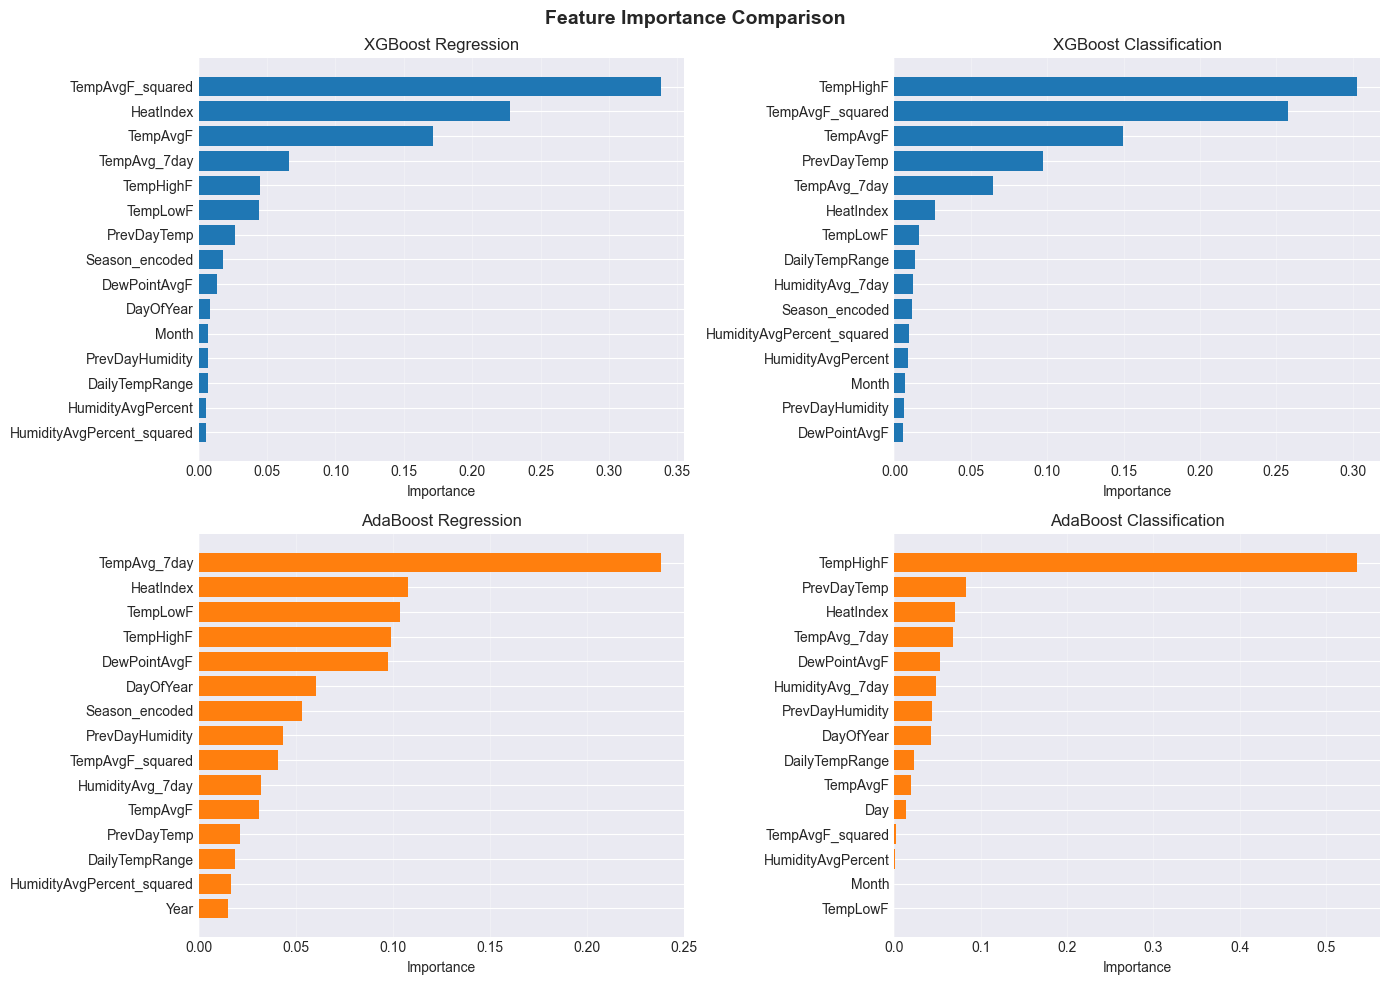


✓ Feature importance plots saved


In [ ]:
# FEATURE IMPORTANCE ANALYSIS
# Extract feature importance from all models and visualize
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Extract feature importance from all four models
# Create DataFrames with features and importance scores, sort by importance
xgb_reg_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_regressor.feature_importances_
}).sort_values('importance', ascending=False)

xgb_cls_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_classifier.feature_importances_
}).sort_values('importance', ascending=False)

ada_reg_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': ada_regressor.feature_importances_
}).sort_values('importance', ascending=False)

ada_cls_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': ada_classifier.feature_importances_
}).sort_values('importance', ascending=False)

# Print top features for each model
print("\nTop 10 Features - XGBoost Regression:")
print(xgb_reg_importance.head(10))
print("\nTop 10 Features - XGBoost Classification:")
print(xgb_cls_importance.head(10))
print("\nTop 10 Features - AdaBoost Regression:")
print(ada_reg_importance.head(10))
print("\nTop 10 Features - AdaBoost Classification:")
print(ada_cls_importance.head(10))

# Visualize feature importance
# Create subplots for all four models using horizontal bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

top_n = 15  # Number of top features to display

# Plot XGBoost Regression feature importance
top_features_xgb_reg = xgb_reg_importance.head(top_n)
axes[0, 0].barh(range(len(top_features_xgb_reg)), top_features_xgb_reg['importance'], color='#1f77b4')
axes[0, 0].set_yticks(range(len(top_features_xgb_reg)))
axes[0, 0].set_yticklabels(top_features_xgb_reg['feature'])
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('XGBoost Regression')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot XGBoost Classification feature importance
top_features_xgb_cls = xgb_cls_importance.head(top_n)
axes[0, 1].barh(range(len(top_features_xgb_cls)), top_features_xgb_cls['importance'], color='#1f77b4')
axes[0, 1].set_yticks(range(len(top_features_xgb_cls)))
axes[0, 1].set_yticklabels(top_features_xgb_cls['feature'])
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('XGBoost Classification')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot AdaBoost Regression feature importance
top_features_ada_reg = ada_reg_importance.head(top_n)
axes[1, 0].barh(range(len(top_features_ada_reg)), top_features_ada_reg['importance'], color='#ff7f0e')
axes[1, 0].set_yticks(range(len(top_features_ada_reg)))
axes[1, 0].set_yticklabels(top_features_ada_reg['feature'])
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('AdaBoost Regression')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot AdaBoost Classification feature importance
top_features_ada_cls = ada_cls_importance.head(top_n)
axes[1, 1].barh(range(len(top_features_ada_cls)), top_features_ada_cls['importance'], color='#ff7f0e')
axes[1, 1].set_yticks(range(len(top_features_ada_cls)))
axes[1, 1].set_yticklabels(top_features_ada_cls['feature'])
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('AdaBoost Classification')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Save visualization
plt.tight_layout()
plt.savefig('models/xgboost_adaboost/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Feature importance plots saved")


## Step 11: Save Models and Predictions

Save trained models and create prediction files for submission.


In [ ]:
# SAVE MODELS AND PREDICTIONS
# Save all trained models and create prediction DataFrames
print("=" * 80)
print("SAVING MODELS AND PREDICTIONS")
print("=" * 80)

# Create output directory
os.makedirs('models/xgboost_adaboost', exist_ok=True)

# Save all models using joblib
# Save XGBoost regressor, XGBoost classifier, AdaBoost regressor, AdaBoost classifier
joblib.dump(xgb_regressor, 'models/xgboost_adaboost/xgb_regression.pkl')
joblib.dump(xgb_classifier, 'models/xgboost_adaboost/xgb_classification.pkl')
joblib.dump(ada_regressor, 'models/xgboost_adaboost/ada_regression.pkl')
joblib.dump(ada_classifier, 'models/xgboost_adaboost/ada_classification.pkl')
print("✓ Models saved")

# Get prediction probabilities for classification models
# Extract probabilities for positive class (class 1) from both classifiers
y_val_pred_xgb_cls_proba = xgb_classifier.predict_proba(X_val)[:, 1]
y_test_pred_xgb_cls_proba = xgb_classifier.predict_proba(X_test)[:, 1]
y_val_pred_ada_cls_proba = ada_classifier.predict_proba(X_val)[:, 1]
y_test_pred_ada_cls_proba = ada_classifier.predict_proba(X_test)[:, 1]

# Extract dates from validation and test data
# Ensure dates match the filtered data (after removing NaNs)
# Need to recreate masks to extract dates from original data
val_mask = ~val_data['heat_index_next_day'].isnull()
test_mask = ~test_data['heat_index_next_day'].isnull()

val_dates = val_data.loc[val_mask, 'Date'].values
test_dates = test_data.loc[test_mask, 'Date'].values

# Create prediction DataFrames
# Include dates, actual values, and predictions for both models
# Include probabilities for classification
predictions_val = pd.DataFrame({
    'Date': val_dates,
    'actual_heat_index': y_val_reg.values,
    'predicted_heat_index_xgb': y_val_pred_xgb_reg,
    'predicted_heat_index_ada': y_val_pred_ada_reg,
    'actual_heat_risk': y_val_cls.values,
    'predicted_heat_risk_xgb': y_val_pred_xgb_cls,
    'predicted_heat_risk_ada': y_val_pred_ada_cls,
    'predicted_heat_risk_xgb_proba': y_val_pred_xgb_cls_proba,
    'predicted_heat_risk_ada_proba': y_val_pred_ada_cls_proba
})

predictions_test = pd.DataFrame({
    'Date': test_dates,
    'actual_heat_index': y_test_reg.values,
    'predicted_heat_index_xgb': y_test_pred_xgb_reg,
    'predicted_heat_index_ada': y_test_pred_ada_reg,
    'actual_heat_risk': y_test_cls.values,
    'predicted_heat_risk_xgb': y_test_pred_xgb_cls,
    'predicted_heat_risk_ada': y_test_pred_ada_cls,
    'predicted_heat_risk_xgb_proba': y_test_pred_xgb_cls_proba,
    'predicted_heat_risk_ada_proba': y_test_pred_ada_cls_proba
})

# Save predictions to CSV files
predictions_val.to_csv('models/xgboost_adaboost/predictions_val.csv', index=False)
predictions_test.to_csv('models/xgboost_adaboost/predictions_test.csv', index=False)
print("✓ Predictions saved")

# Verify that all files were saved
# Check existence of model files and prediction files
print("\nVerifying saved files:")
for file in ['xgb_regression.pkl', 'xgb_classification.pkl',
             'ada_regression.pkl', 'ada_classification.pkl',
             'predictions_val.csv', 'predictions_test.csv']:
    path = f'models/xgboost_adaboost/{file}'
    if os.path.exists(path):
        print(f"  ✓ {file} exists")
    else:
        print(f"  ✗ {file} not found!")


SAVING MODELS AND PREDICTIONS
✓ Models saved
✓ Predictions saved

Verifying saved files:
  ✓ xgb_regression.pkl exists
  ✓ xgb_classification.pkl exists
  ✓ ada_regression.pkl exists
  ✓ ada_classification.pkl exists
  ✓ predictions_val.csv exists
  ✓ predictions_test.csv exists


## Summary

After completing all sections, you should have:
- ✅ Features prepared and encoded
- ✅ XGBoost regressor and classifier trained
- ✅ AdaBoost regressor and classifier trained
- ✅ Models evaluated and compared
- ✅ Feature importance analyzed
- ✅ Models saved to `models/xgboost_adaboost/`
- ✅ Predictions saved to CSV files

**Key Differences**:
- **XGBoost**: Gradient boosting with regularization, handles missing values, generally faster
- **AdaBoost**: Adaptive boosting, simpler but can be slower
- Compare performance to determine which model performs better for your data

**Next Steps**:
- Review `models/xgboost_adaboost/README.md` for submission requirements
- Ensure all deliverables are complete
- Proceed to `ensemble.ipynb` after all models complete their models
